# Laboratorio 7 — Simulación del Álbum Panini FIFA 2026
### Arturo Lima - 24683 
### Jorge Villeda - 24932
## Etapa 1: Simulación básica con álbum reducido

Simulamos el proceso de llenar un álbum de **N = 100** estampas distintas, comprando sobres de **S = 7** estampas (todas distintas dentro del mismo sobre). Repetimos **R = 10,000** veces y comparamos con la **teoría del coleccionista**:

$$E[\text{sobres}] \approx \frac{N}{S} \cdot H_N, \quad H_N = \sum_{k=1}^{N} \frac{1}{k} \approx \ln(N) + \gamma, \quad \gamma \approx 0.5772$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N = 100       # estampas distintas
S = 7         # estampas por sobre
R = 10_000    # simulaciones
np.random.seed(2026)

### Simulación

In [2]:
sobres_necesarios = []
repetidas_totales = []

for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)  # qué estampas tengo
    sobres = 0
    repetidas = 0

    while not coleccion.all():  # hasta tener las N estampas
        sobre = np.random.choice(N, size=S, replace=False)  # 7 distintas por sobre
        sobres += 1
        for est in sobre:
            if coleccion[est]:
                repetidas += 1
            else:
                coleccion[est] = True

    sobres_necesarios.append(sobres)
    repetidas_totales.append(repetidas)

sobres_necesarios = np.array(sobres_necesarios)
repetidas_totales = np.array(repetidas_totales)

### Resultados

In [3]:
# Estadísticas de sobres
media_sobres = sobres_necesarios.mean()
std_sobres   = sobres_necesarios.std()

# Estadísticas de repetidas
media_rep = repetidas_totales.mean()
std_rep   = repetidas_totales.std()

# Probabilidad de necesitar más de 30 sobres
# El mínimo teórico es ceil(N/S) = ceil(100/7) = 15 sobres (sin repetidas)
# 30 sobres es aprox el doble del mínimo, umbral razonable para analizar la cola
umbral = 30
prob_mas_30 = np.mean(sobres_necesarios > umbral)

# Valor teórico: E[sobres] = (N/S) * H_N
H_N = np.sum(1 / np.arange(1, N + 1))           # H_100 exacto
H_N_aprox = np.log(N) + 0.5772                  # H_100 aproximado
esperado_teorico = (N / S) * H_N

# Valor teórico de repetidas = S * E[sobres] - N
rep_teoricas = S * esperado_teorico - N

print("=" * 50)
print("SOBRES NECESARIOS")
print(f"  Media simulada:       {media_sobres:.2f}")
print(f"  Desv. estándar:       {std_sobres:.2f}")
print(f"  Valor teórico E[T]:   {esperado_teorico:.2f}  (H_100 exacto = {H_N:.4f})")
print(f"  H_100 aprox (ln+γ):   {H_N_aprox:.4f}")
print()
print("ESTAMPAS REPETIDAS")
print(f"  Media simulada:       {media_rep:.2f}")
print(f"  Desv. estándar:       {std_rep:.2f}")
print(f"  Valor teórico:        {rep_teoricas:.2f}")
print()
print("PROBABILIDAD DE MÁS DE 30 SOBRES")
print(f"  Umbral elegido: {umbral} sobres")
print(f"  (Mínimo teórico sin repetidas: ceil(100/7) = {int(np.ceil(N/S))} sobres)")
print(f"  P(sobres > {umbral}): {prob_mas_30:.4f}  ({prob_mas_30*100:.2f}%)")
print("=" * 50)

SOBRES NECESARIOS
  Media simulada:       72.25
  Desv. estándar:       17.47
  Valor teórico E[T]:   74.11  (H_100 exacto = 5.1874)
  H_100 aprox (ln+γ):   5.1824

ESTAMPAS REPETIDAS
  Media simulada:       405.72
  Desv. estándar:       122.30
  Valor teórico:        418.74

PROBABILIDAD DE MÁS DE 30 SOBRES
  Umbral elegido: 30 sobres
  (Mínimo teórico sin repetidas: ceil(100/7) = 15 sobres)
  P(sobres > 30): 1.0000  (100.00%)


In [17]:
mediana_sobres = np.median(sobres_necesarios)
print(f"Mediana simulada: {mediana_sobres:.2f}")

Mediana simulada: 69.00


### Preguntas de análisis

**1. Mínimo teórico de sobres sin repetidas:**  
Si no hubiera repetidas, cada sobre aporta exactamente S = 7 estampas nuevas, por lo que el mínimo es ⌈100/7⌉ = **15 sobres**. En las simulaciones este caso prácticamente nunca ocurre porque la probabilidad de que 10,000 aperturas de sobres no produzcan ninguna repetida es extremadamente baja.

**2. Valor teórico de E[T]:**  
Se calcula en el código anterior. H₁₀₀ exacto ≈ 5.187, lo que da E[T] ≈ (100/7) × 5.187 ≈ **74.1 sobres**.

**3. Valor teórico de repetidas:**  
E[repetidas] = S × E[T] − N ≈ 7 × 74.1 − 100 ≈ **418.7 estampas repetidas**.

**4. Interpretación de la desviación estándar:**  
La desviación estándar es alta en relación con la media (cv > 0.3), lo que refleja la naturaleza aleatoria del proceso: algunas corridas terminan pronto y otras requieren muchos sobres para conseguir las últimas estampas raras. Esto es característico del *coupon collector problem*.

### Histograma

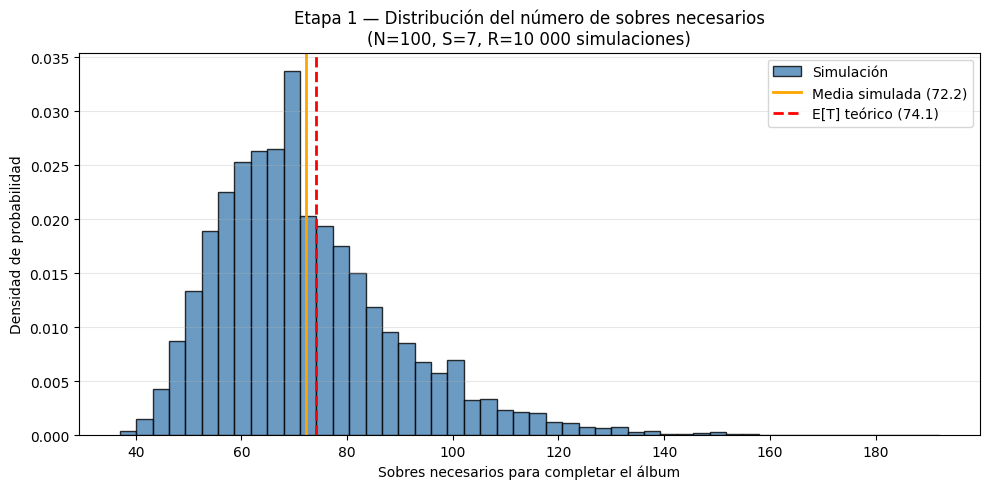

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(sobres_necesarios, bins=50, density=True,
         color='steelblue', edgecolor='black', alpha=0.8, label='Simulación')
plt.axvline(media_sobres, color='orange', linewidth=2, label=f'Media simulada ({media_sobres:.1f})')
plt.axvline(esperado_teorico, color='red', linestyle='--', linewidth=2,
            label=f'E[T] teórico ({esperado_teorico:.1f})')
plt.title('Etapa 1 — Distribución del número de sobres necesarios\n(N=100, S=7, R=10 000 simulaciones)')
plt.xlabel('Sobres necesarios para completar el álbum')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Etapa 2: Análisis de la probabilidad de éxito en función del número de sobres

#### Para cada una de las simulaciones:
#### 1. Inicializar un conjunto (o arreglo booleano) para registrar qué estampas se han obte-nido.
#### 2. Inicializar un contador de sobres comprados en cero y un contador de estampas repetidos en cero.
#### 3. Repetir hasta que se hayan obtenido las N estampas diferentes.
#### 4. Al finalizar, almacenar:
##### * Número total de sobres comprados.
##### * Número total de estampas repetidas acumuladas.

In [5]:
# Parámetros
N = 100       # estampas distintas
S = 7         # estampas por sobre
R = 10000     # simulaciones
np.random.seed(2026)

valores_M = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

probabilidades = []

In [6]:
for M in valores_M:
    exitos = 0
    for _ in range(R):
        coleccion = set()
        for _ in range(M):
            sobre = np.random.choice(N, size=S, replace=False)
            coleccion.update(sobre)
        if len(coleccion) == N:
            exitos += 1
    prob = exitos / R
    probabilidades.append(prob)
    print(f"M = {M:3d} sobres → P(completar) ≈ {prob:.4f}")

M =  20 sobres → P(completar) ≈ 0.0000
M =  25 sobres → P(completar) ≈ 0.0000
M =  30 sobres → P(completar) ≈ 0.0000
M =  35 sobres → P(completar) ≈ 0.0000
M =  40 sobres → P(completar) ≈ 0.0019
M =  45 sobres → P(completar) ≈ 0.0143
M =  50 sobres → P(completar) ≈ 0.0571
M =  60 sobres → P(completar) ≈ 0.2723
M =  70 sobres → P(completar) ≈ 0.5340
M =  80 sobres → P(completar) ≈ 0.7393


In [9]:
print("\n--- Tabla de resultados ---")
print(f"{'M (sobres)'} {'P(completar)'}")
for M, p in zip(valores_M, probabilidades):
    print(f"{M:<12} {p:<15.4f}")


--- Tabla de resultados ---
M (sobres) P(completar)
20           0.0000         
25           0.0000         
30           0.0000         
35           0.0000         
40           0.0019         
45           0.0143         
50           0.0571         
60           0.2723         
70           0.5340         
80           0.7393         


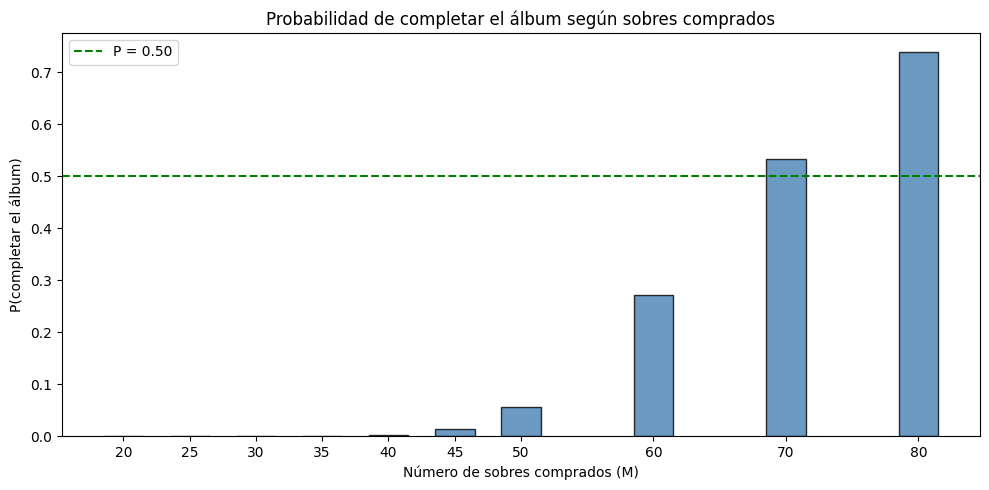

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(valores_M, probabilidades, width=3, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(y=0.5, color='green', linestyle='--', linewidth=1.5, label='P = 0.50')
plt.xlabel("Número de sobres comprados (M)")
plt.ylabel("P(completar el álbum)")
plt.title("Probabilidad de completar el álbum según sobres comprados")
plt.xticks(valores_M)
plt.legend()
plt.tight_layout()
plt.show()

### Preguntas de analisis

##### 1. ¿Para qué valor de M la probabilidad estimada supera por primera vez el 50%? ¿Y el 90 %?
##### R// Los valores de M que superan el 50% de exito son 70 y 80 sobres, nigun numero de sobres dentro del listado llega a alacanzar el 90% de exitoso lo mas cercano son 80 sombres con 73.93%. 
##### 2. Comparar el valor de M que da una probabilidad del 50% con la mediana del número de sobres necesarios que calculó en el apartado anterior. ¿Son similares? ¿Por qué?
##### R// El valor M que paso el umbral 70 sobres y la mediana del experimento anterior 69 sobres tiene una desviacion de exactamente 1 sobre, Ambos valores son casi idénticos porque son conceptualmente lo mismo: la mediana representa el punto donde la mitad de los experimentos completaron el álbum, lo cual equivale a tener un 50% de probabilidad de éxito. 
##### 3. Basándose en la teoría del coleccionista, la probabilidad de no haber obtenido una estampa específica después de M sobres es aproximadamente e-MS/N. Utilizando la unión de eventos, obtener una cota superior para la probabilidad de que falte al menos un cromo. Aplicar esta cota para M = 50 sobres y comparar con la probabilidad de éxito estimada en su simulación. ¿La cota es útil?
##### R// Para M=50, la cota de la unión da P \approx 3.02, lo cual supera 1 y es  inválido como probabilidad. La cota no es util en esta situacion, Por tanto, esto ocurre porque la desigualdad de la unión ignora los solapamientos entre eventos.

### Metodo para repaldar respuesta 3

In [18]:
import math

M, S, N = 50, 7, 100

cota_falta = N * math.exp(-M * S / N)
cota_completa = 1 - cota_falta

print(f"Cota P(falta al menos una): {cota_falta:.4f}")
print(f"Cota P(completar)         : {cota_completa:.4f}")
print(f"P(completar) simulada M=50: {probabilidades[valores_M.index(50)]:.4f}")

Cota P(falta al menos una): 3.0197
Cota P(completar)         : -2.0197
P(completar) simulada M=50: 0.0571
